In [7]:
from qsopt import * 
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import qutip

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")

JAX version: 0.9.2
QuTiP version: 5.2.2


## Define experimental parameters

In [8]:
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 1

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = inverse_pulse_width      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, 0.0, 8.0])/inverse_pulse_width) 
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.0001,  
    dephasing = 0.0001,      
    relaxation = 0.0001
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Number of qubits:          1
  Cavity levels:             2
  Qubit levels:         [2]
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                  [7.5]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   None
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      3
  Measurement times:    [-8.0, 0.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0001]
  Dephasing rate:       [0.0001]
  Relaxation rate:      [0.0001]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: results/pulse_shape.png


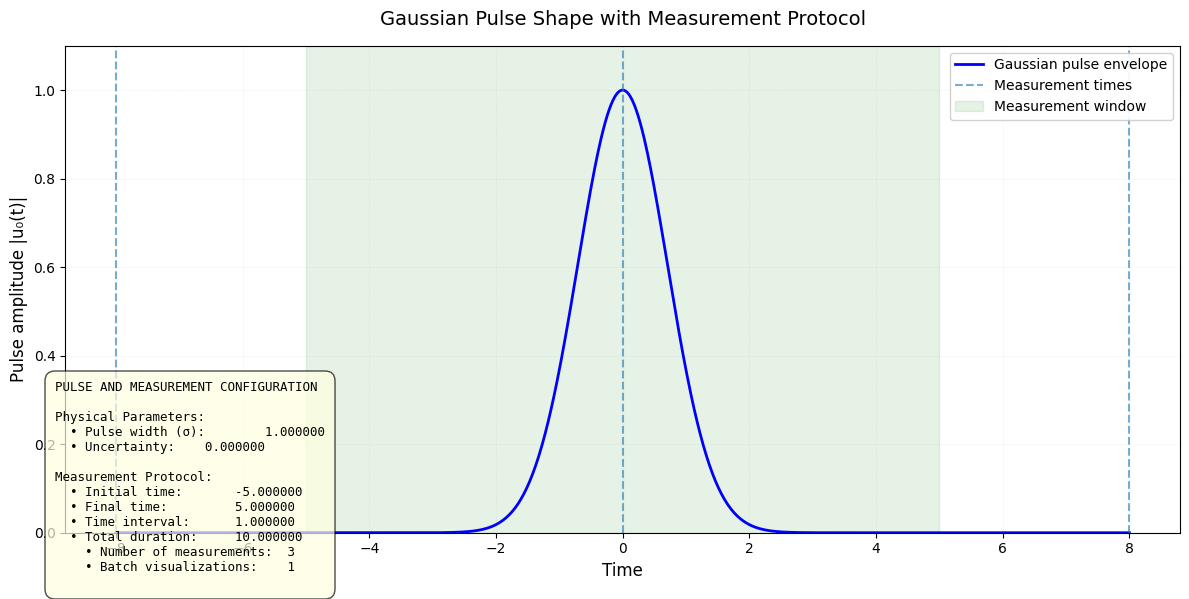

In [9]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=1
)
fig.show()

## Define quantum circuits

The interface uses `QuantumCircuit` objects to define the gates applied before and after evolution.

In [10]:
from qsopt.core.circuit import create_ry_circuit
initial_circuit = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])#, trainable=False)
final_circuit = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])

# The circuits contain trainable parameters that will be optimized
print(f"Initial circuit parameters: {initial_circuit.get_trainable_parameters()}")
print(initial_circuit)
print(f"Final circuit parameters: {final_circuit.get_trainable_parameters()}")
print(final_circuit)

Initial circuit parameters: [Array(1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=1.571)
Final circuit parameters: [Array(-1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=-1.571)


## Define experiment

In [11]:
detection_metric = DetectionMetric(n_qubits=1, detection_criterion = 'max computational distance', detection_param=(lambda x, y: jnp.power(x - y, 2), 0.5))

print(detection_metric)

experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
    detection_metric=detection_metric
)


DetectionMetric: max computational distance with computational distance
detection criterion:
  'max computational distance'
metric:
  'computational distance'
batching logic:
  'max computational distance batching'
multiple measurement logic:
  'list aggregation'



## Test Single Simulation

In [12]:
results = experiment.run_simulation(debug=False)
print(results)

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    -0.500358
     Without photon: 0.000000
     Metric:            -0.500358


## Time Evolution

In [13]:
'''result = experiment.time_evolution(n_points=300, with_interaction=True)
print(result)

from qsopt.utils.visualization import plot_time_evolution
plot_time_evolution(
    evolution_data=result,
    show_pulse=True,
    show_measurements=True,
    show_cavity_population=True,  # Cavity population (purple)
    show_field_population=True,   # External field population (brown)
    title='Single Qubit Evolution',
    figsize=(10, 6)
)
plt.show()'''

"result = experiment.time_evolution(n_points=300, with_interaction=True)\nprint(result)\n\nfrom qsopt.utils.visualization import plot_time_evolution\nplot_time_evolution(\n    evolution_data=result,\n    show_pulse=True,\n    show_measurements=True,\n    show_cavity_population=True,  # Cavity population (purple)\n    show_field_population=True,   # External field population (brown)\n    title='Single Qubit Evolution',\n    figsize=(10, 6)\n)\nplt.show()"

## Run Optimization

In [14]:
import optax

# Use an explicit callback so this history is not overwritten by later optimizations
history_callback = OptimizationCallback(save_every=1, save_best=True)

history = experiment.optimize_rotations(
    initial_values=[1.3, -1.0], 
    num_steps=250,
    verbose=True,
    verbose_step=50,
    batch_size=1,
    tolerance=1e-7,
    callback=history_callback,
    optimizer=optax.sgd(learning_rate=0.05)
)

Configuration:
    Max iterations: 250
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection metric: max computational distance with computational distance
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.300  rad (74.5°)
        param1.  reset_RY[0]  = -1.000 rad (-57.3°)
Step  setup0_RY[0]   reset0_RY[0]   Metric      Grad Norm   Time
---------------------------------------------------------------------


0     1.300000       -1.000000      -0.569225   2.82e-01    00h00m07s
1     1.313449       -1.004293      -0.565262   2.79e-01    00h00m07s
2     1.326796       -1.008355      -0.561392   2.76e-01    00h00m07s
50    1.816663       -1.017227      -0.455953   1.34e-01    00h00m15s
100   2.003467       -0.991591      -0.439690   3.50e-02    00h00m23s
150   2.054793       -1.009586      -0.438405   1.39e-02    00h00m31s
200   2.074463       -1.025936      -0.438136   7.28e-03    00h00m39s
Final gradient norm: 3.95e-03
Best metric: -0.438060
Best parameters:
    param0. setup_RY[0](param=2.084)=2.084 rad (119.4°)
    param1. reset_RY[0](param=-1.035)=-1.035 rad (-59.3°)


In [15]:
print(history)

MODE: Optimization
     Total iterations: 250
     Best epoch:        250
     Converged: False
     Final gradient norm: 3.952570e-03
  Best Parameters:
     Initial circuit:
        param_0: 2.083953 rad (119.40°)
     Final circuit:
        param_0: -1.035438 rad (-59.33°)
  Detection Measures:
     With photon:    -0.438060
     Without photon: 0.000000
     Metric:            -0.438060


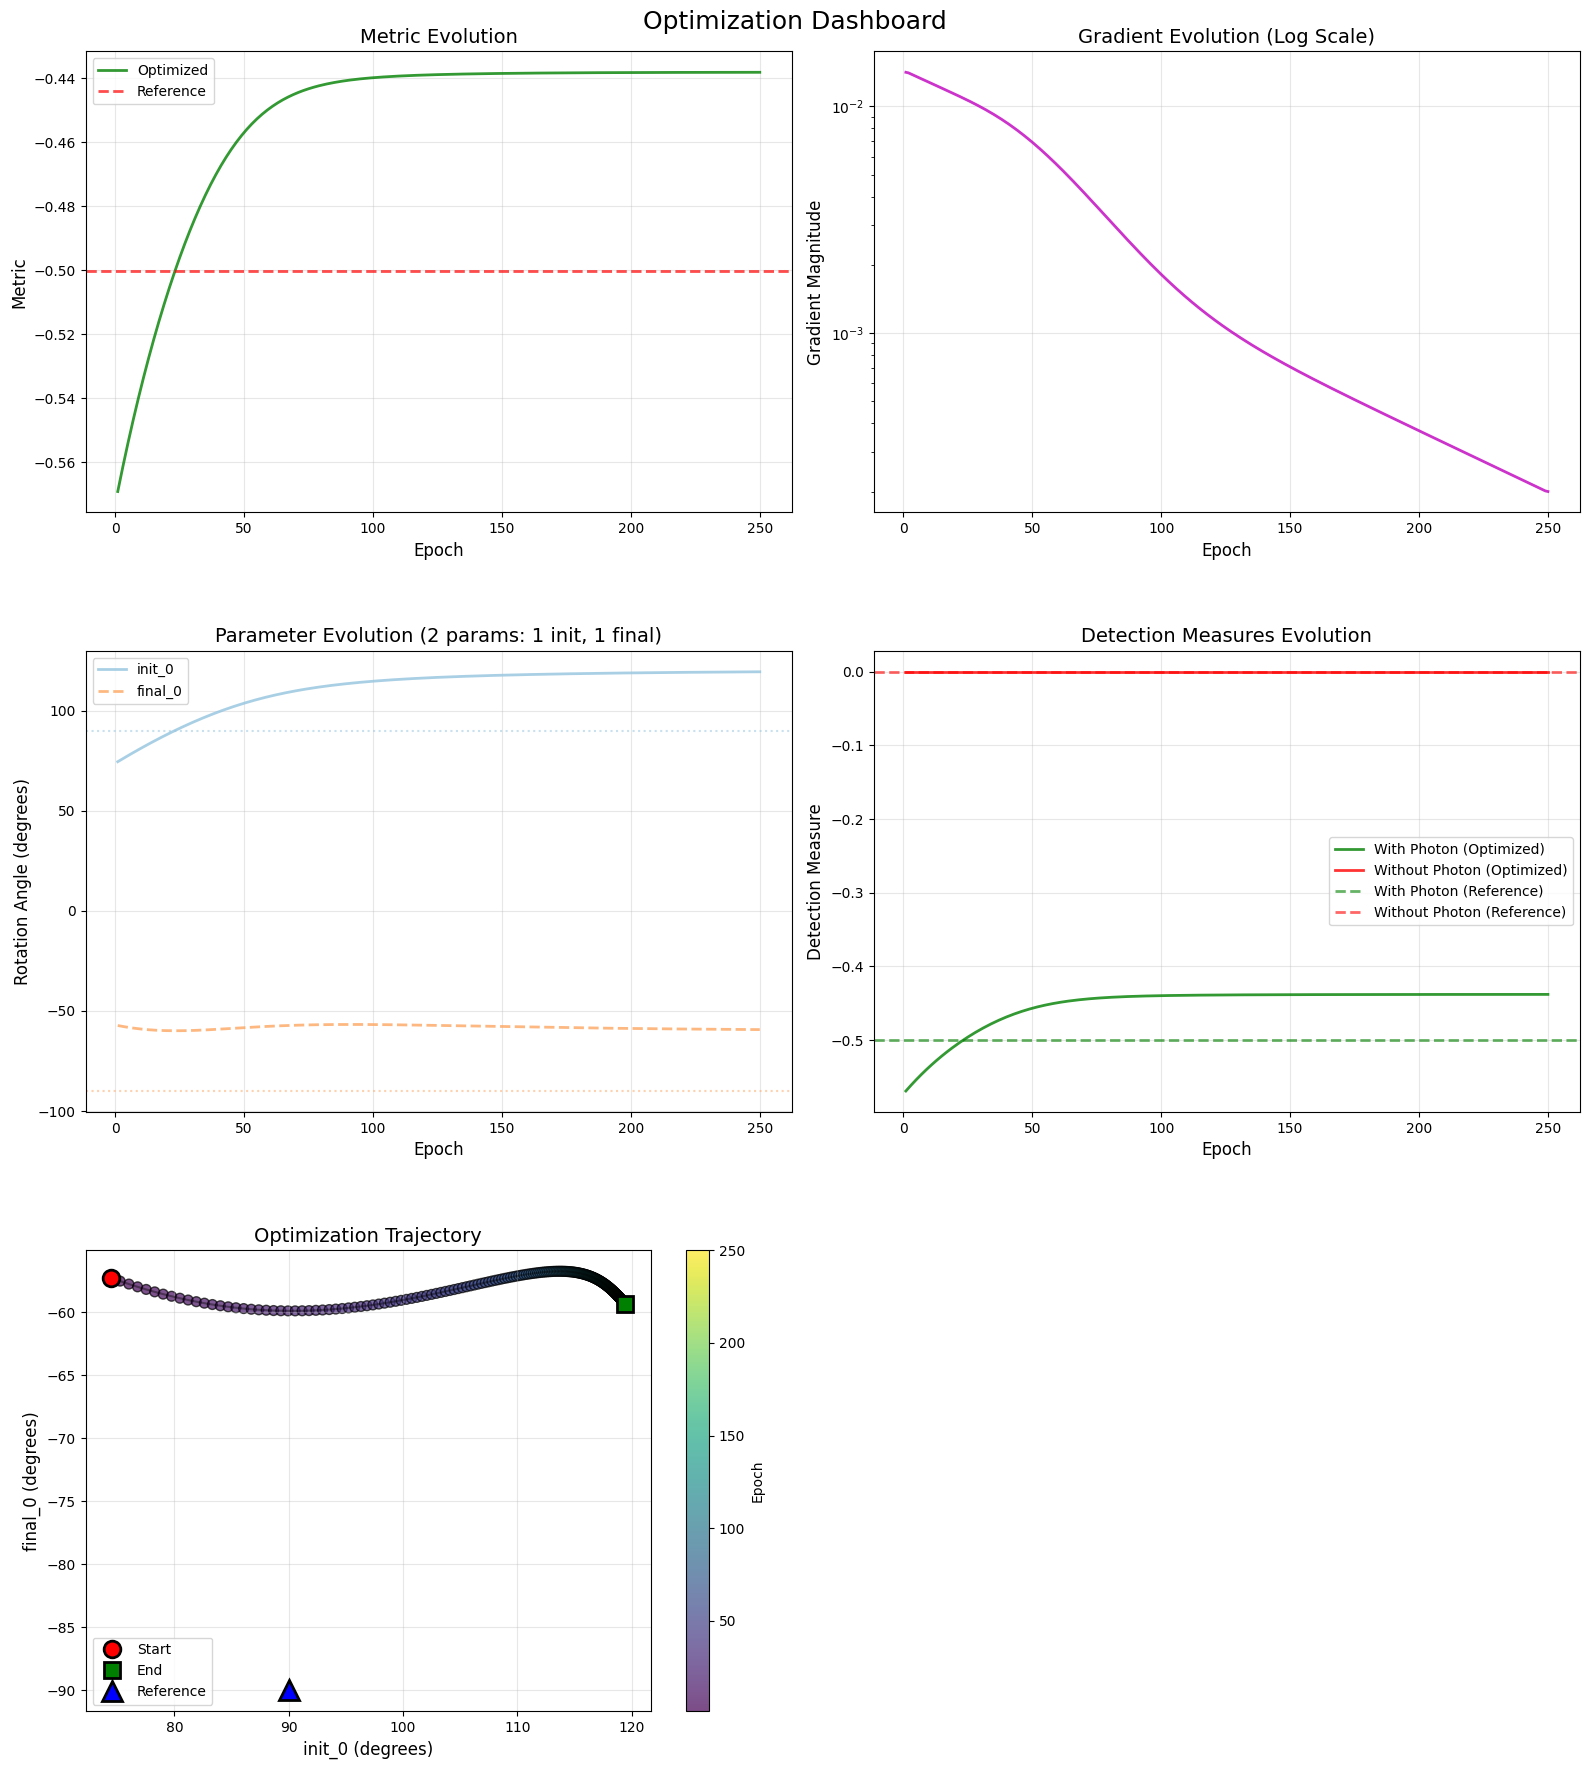

In [16]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times

In [17]:
# time_callback = experiment.optimize_measurement_times(batch_size=1, mode='discrete', verbose=True)

In [18]:
# from qsopt.utils.visualization import plot_time_interval_landscape

# fig = plot_time_interval_landscape(
#     landscape_data=time_callback,
#     exp_params=experiment.experimental_params,
#     save_path='results/time_interval_opt.pdf'
# )


## Sweep chi-gamma

In [19]:
results_sweep = experiment.sweep_chi_gamma(
    chi_interval=[1.0, 30.0],
    gamma_interval=[1.0, 60.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [1.00, 30.00] (linear scale)
  γ range: [1.00, 60.00] (linear scale)


KeyboardInterrupt: 

SweepResults:
  Parameter 1: gamma
    Interval: [1, 60]
    Scale: linear
    Resolution: 10 points
  Parameter 2: chi
    Interval: [1, 30]
    Scale: linear
    Resolution: 10 points
  Available results: detection_map, detection_without_map, metric_map
  Optimal point: chi=30, gamma=60


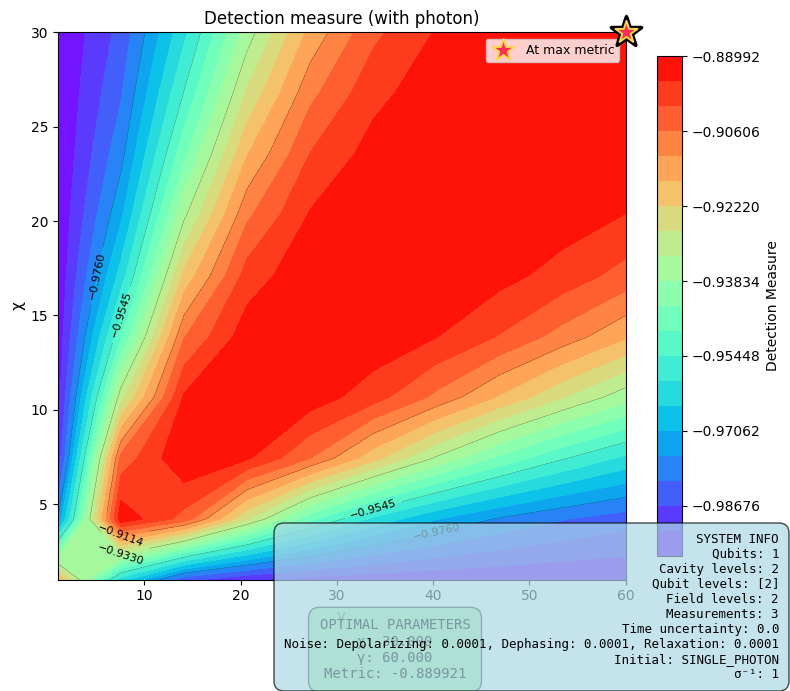

In [ ]:
from qsopt.utils.visualization import plot_sweep_results

print(results_sweep)

plot_sweep_results(
    results_sweep,
    results_to_plot=['detection_map'],
    figsize=(8, 7)
)
plt.show()

## Continue Optimization From a Saved Callback

You can stop and resume optimization by saving the callback to disk and loading it back with `OptimizationCallback.load_callback`.
This restores both parameters and optimizer state (and gradients), so `hot_start=True` continues from the saved point.

In [ ]:
history.save('results/single_qubit_hotstart.npz')

loaded_history = OptimizationCallback.load_callback('results/single_qubit_hotstart.npz')

history_resumed = experiment.optimize_rotations(
    num_steps=10,
    batch_size=1,
    verbose=True,
    verbose_step=1,
    tolerance=1e-7,
    callback=loaded_history,
    optimizer=optax.sgd(learning_rate=0.5),
    hot_start=True,
)

print(history_resumed)

print('\n' + '-' * 80 + '\n')

# Build a fresh experiment for a clean 15-step baseline from the same initial values
baseline_experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=create_ry_circuit(n_qubits=1, theta_values=[np.pi / 2]),
    final_circuit=create_ry_circuit(n_qubits=1, theta_values=[-np.pi / 2]),
    detection_metric=detection_metric,
 )

continued_callback = OptimizationCallback(save_every=1, save_best=True)
history_continued = baseline_experiment.optimize_rotations(
    initial_values=[1.3, -1.0], 
    num_steps=15,
    verbose=True,
    verbose_step=1,
    batch_size=1,
    tolerance=1e-7,
    callback=continued_callback,
    optimizer=optax.sgd(learning_rate=0.5)
)

print(history_continued)

m_resumed = np.array(history_resumed.history['metric'], dtype=float)
m_continued = np.array(history_continued.history['metric'], dtype=float)
n_overlap = min(len(m_resumed), len(m_continued))
print(f'len(resumed)={len(m_resumed)}, len(continued)={len(m_continued)}')
print('max_abs_metric_diff_on_overlap=', float(np.max(np.abs(m_resumed[:n_overlap] - m_continued[:n_overlap]))))

Starting hot start optimization, trying to load last parameters, optimizer state, and gradients from callback:
- Parameters LOADED
- Gradients LOADED
- Optimizer state LOADED
Resuming from epoch 250, running until epoch 260
Configuration:
    Max iterations: 260
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection metric: max computational distance with computational distance
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 2.033  rad (116.5°)
        param1.  reset_RY[0]  = -0.800 rad (-45.9°)
Step  setup0_RY[0]   reset0_RY[0]   Metric      Grad Norm   Time
---------------------------------------------------------------------


250   2.033292       -0.800331      -0.890343   8.65e-03    00h00m08s
251   2.035976       -0.803722      -0.890306   8.50e-03    00h00m08s
252   2.038622       -0.807049      -0.890270   8.36e-03    00h00m08s
253   2.041229       -0.810313      -0.890235   8.21e-03    00h00m08s
254   2.043798       -0.813516      -0.890202   8.07e-03    00h00m08s
255   2.046328       -0.816658      -0.890169   7.93e-03    00h00m09s
256   2.048820       -0.819739      -0.890138   7.79e-03    00h00m09s
257   2.051274       -0.822761      -0.890108   7.65e-03    00h00m09s
258   2.053690       -0.825724      -0.890079   7.51e-03    00h00m09s
259   2.056068       -0.828630      -0.890051   7.37e-03    00h00m09s
Final gradient norm: 7.37e-03
Best metric: -0.890051
Best parameters:
    param0. setup_RY[0](param=2.056)=2.056 rad (117.8°)
    param1. reset_RY[0](param=-0.829)=-0.829 rad (-47.5°)
MODE: Optimization
     Total iterations: 260
     Best epoch:        260
     Converged: False
     Final gradient 

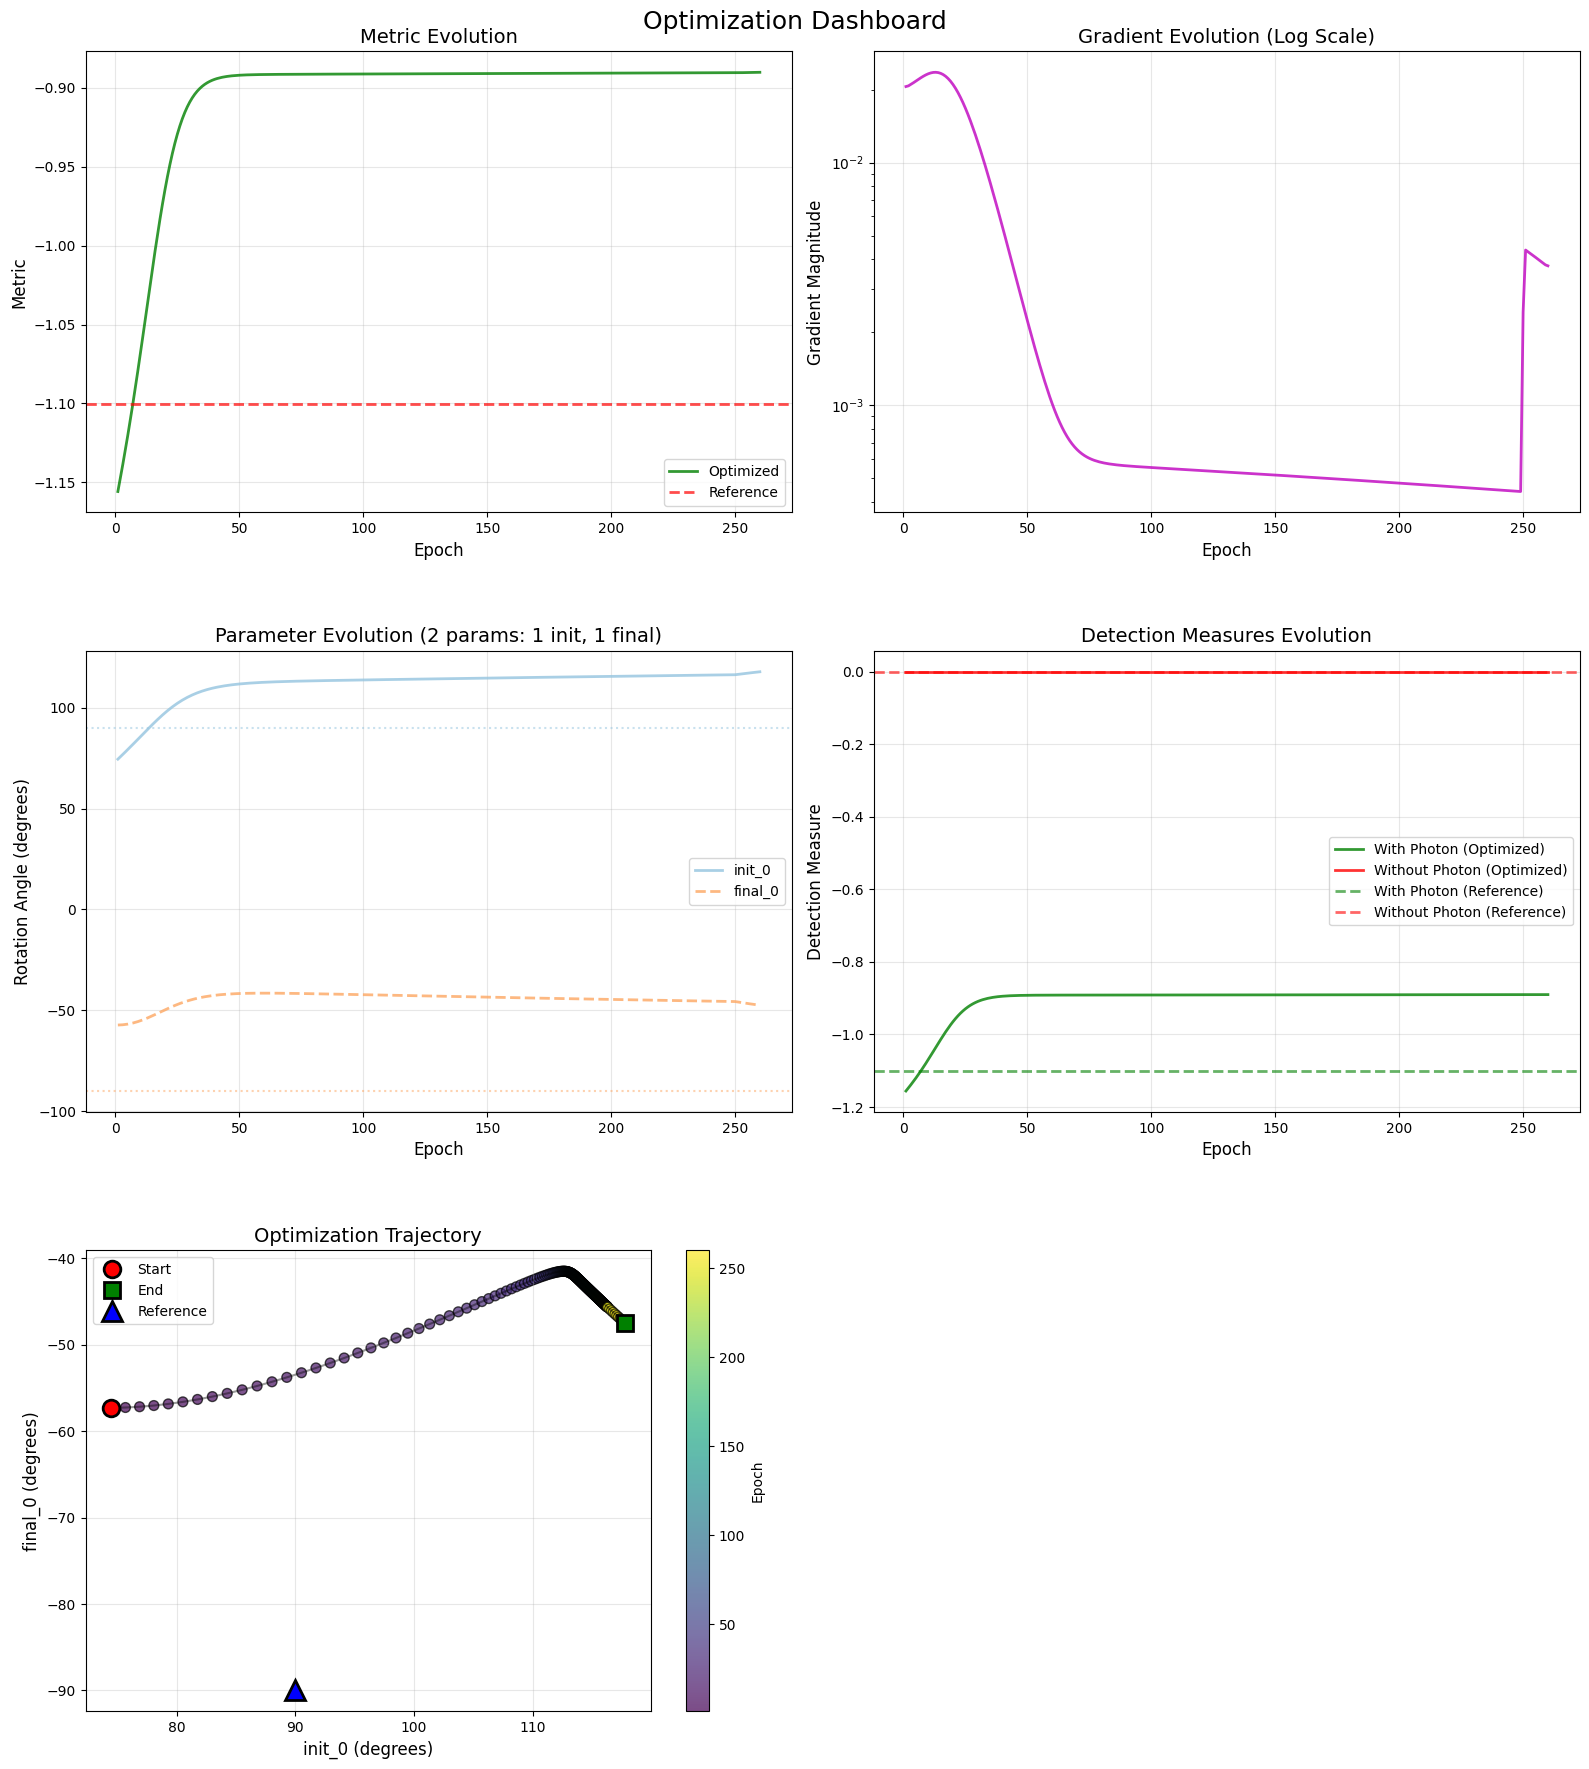

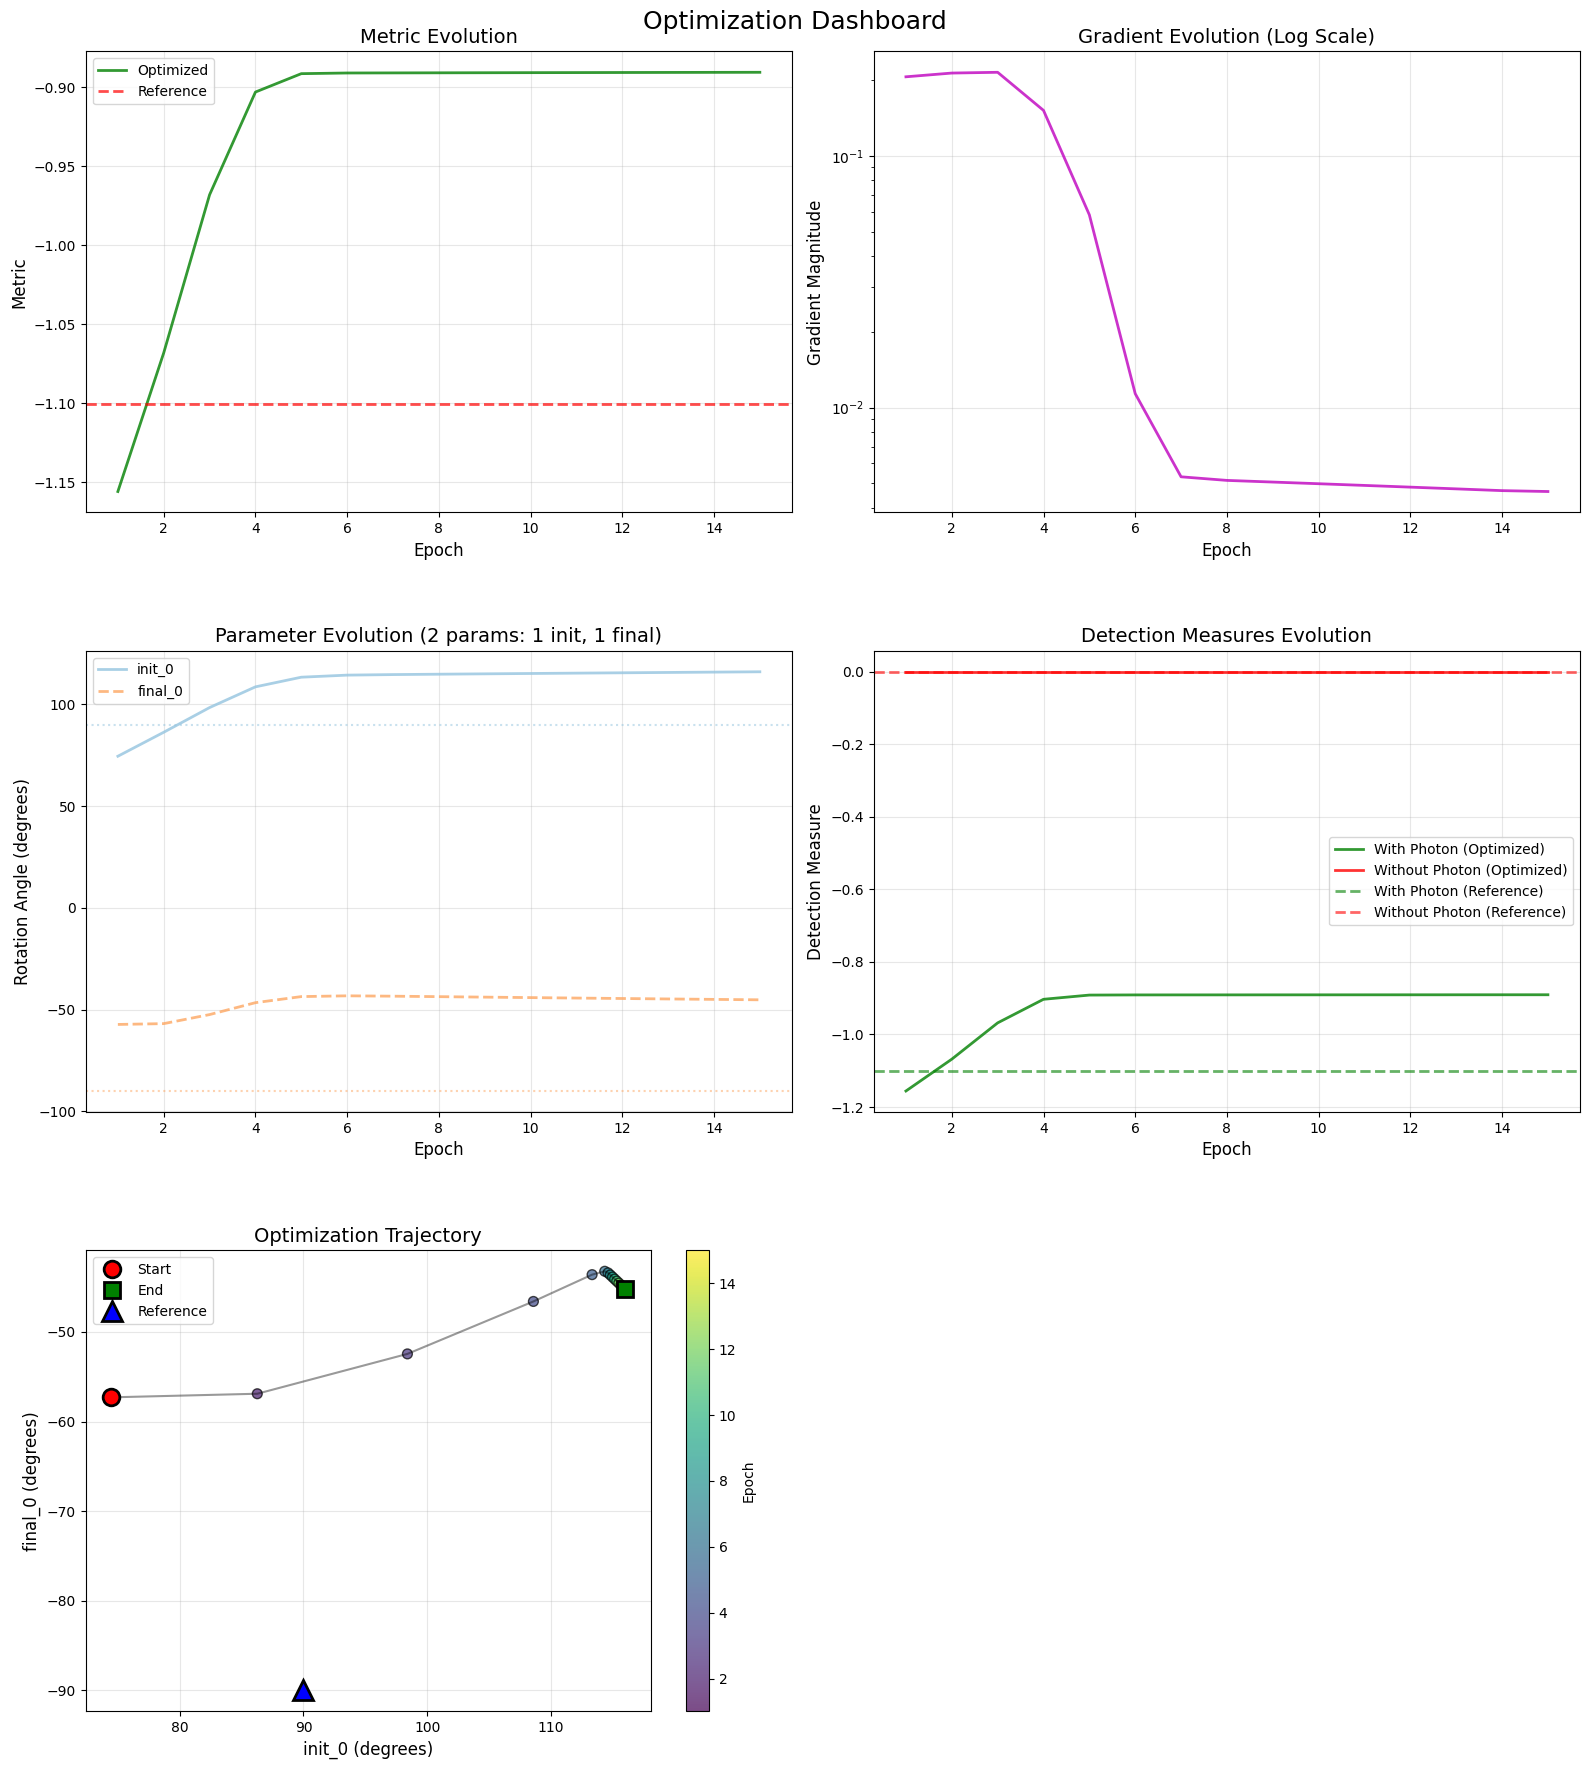

In [ ]:
# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_resumed,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_continued,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

In [ ]:
import numpy as np

res_epochs = np.array(history_resumed.history.get('epochs', []), dtype=int)
res_metric = np.array(history_resumed.history.get('metric', []), dtype=float)

cont_epochs = np.array(history_continued.history.get('epochs', []), dtype=int)
cont_metric = np.array(history_continued.history.get('metric', []), dtype=float)

print('resumed_epochs:', res_epochs.tolist())
print('resumed_metric:', res_metric.tolist())
print('continued_epochs:', cont_epochs.tolist())
print('continued_metric:', cont_metric.tolist())

n = min(len(res_metric), len(cont_metric))
print('overlap_len:', n)
if n > 0:
    diffs = np.abs(res_metric[:n] - cont_metric[:n])
    print('overlap_abs_diff:', diffs.tolist())
    print('max_abs_diff_overlap:', float(np.max(diffs)))

print('history_epochs:', history.history.get('epochs', []))
print('history_metric:', history.history.get('metric', []))

resumed_epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 2